In [2]:
%load_ext autoreload
%autoreload 2

In [1]:
import torch
from torchvision import transforms

from stedfm.modules.transforms import CropToDivisible
from stedfm.datasets import get_dataset

dataset = get_dataset(
    name="MCSTED",
    path="/home-local2/projects/FLCDataset/STED-FM-dataset-full-images-multichannel-sted.tar",
    debug=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        CropToDivisible(divisor=16)
    ])
)
print("Dataset loaded successfully.")
print(f"Number of samples in the dataset: {len(dataset)}")

Dataset loaded successfully.
Number of samples in the dataset: 44121


In [2]:
import numpy
import random
from skimage.filters import threshold_otsu
from tqdm.auto import trange, tqdm

def extract_patches_with_foreground(sample, patch_size=(16,16), subsample_factor=1):
    patches = []

    C, H, W = sample.shape
    ph, pw = patch_size
    h_blocks = H // ph
    w_blocks = W // pw

    for channel_idx in range(sample.shape[0]):
        channel_data = sample[channel_idx]
        thresh = threshold_otsu(channel_data)
        binary_mask = channel_data > thresh
        
        # reshape into blocks: (h_blocks, ph, w_blocks, pw)
        resh = channel_data.reshape(h_blocks, ph, w_blocks, pw)
        mask_resh = binary_mask.reshape(h_blocks, ph, w_blocks, pw)

        # compute foreground fraction per block
        fg_counts = mask_resh.sum(axis=(1,3))  # shape (h_blocks, w_blocks)
        keep = fg_counts > (0.25 * (ph * pw))

        if not keep.any():
            continue

        # extract all block patches as (h_blocks*w_blocks, ph, pw)
        blocks = resh.transpose(0,2,1,3).reshape(-1, ph, pw)
        keep_flat = keep.ravel()
        patches_c = blocks[keep_flat]
        patches.extend(list(patches_c))

    if subsample_factor < 1:
        patches = random.sample(patches, int(len(patches) * subsample_factor))

    return patches

patches = []
random.seed(42)
indices = list(range(len(dataset)))
indices = random.sample(indices, int(0.1 * len(indices)))  # subsample indices for faster testing
for i in tqdm(indices):
    sample = dataset[i]
    sample = sample.cpu().numpy()
    
    patches.extend(extract_patches_with_foreground(sample, subsample_factor=0.1))
print(f"Extracted {len(patches)} patches with foreground.")
    

  0%|          | 0/4412 [00:00<?, ?it/s]

Extracted 298486 patches with foreground.


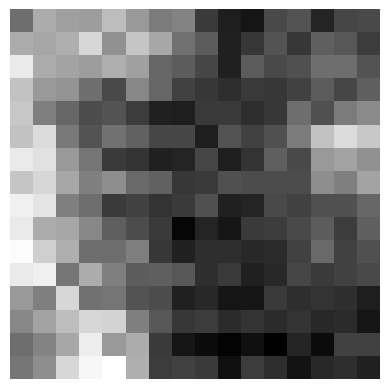

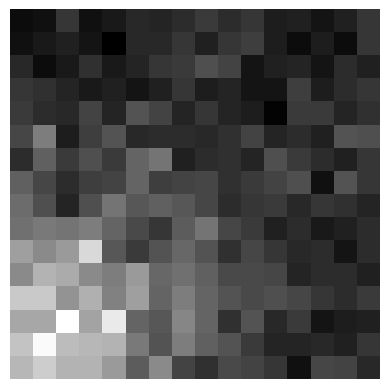

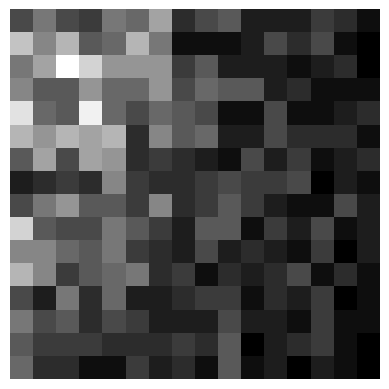

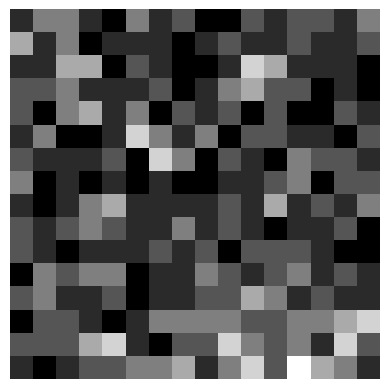

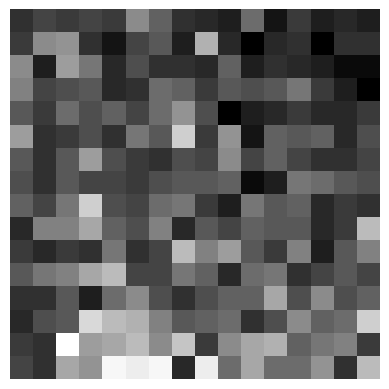

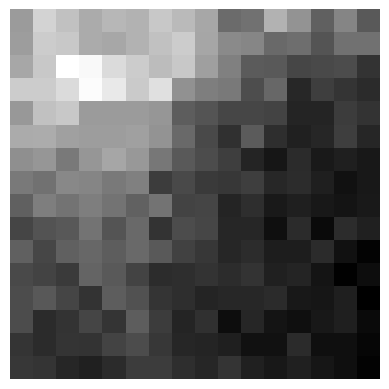

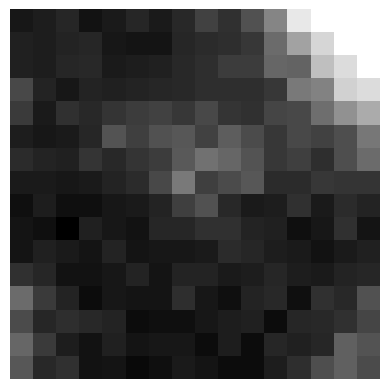

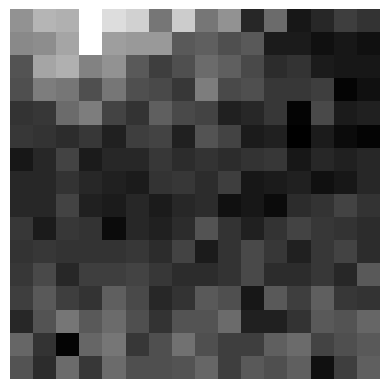

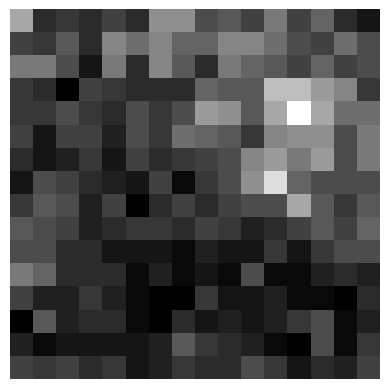

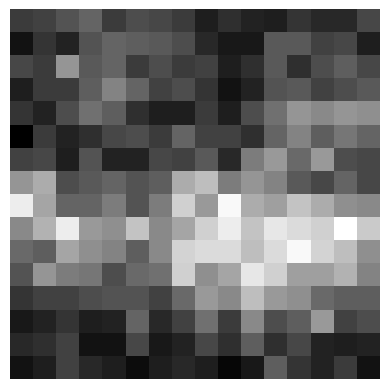

In [6]:
import random
from matplotlib import pyplot

random_patches = random.sample(patches, 10)
for idx, patch in enumerate(random_patches):
    fig, ax = pyplot.subplots(frameon=False)
    ax.imshow(patch, cmap='gray')
    ax.axis('off')
    pyplot.show()

# Learn dictionary

In [13]:

data = numpy.array(patches)
data = data.reshape(data.shape[0], -1)  # Flatten patches for dictionary learning

X_mean = numpy.mean(data, axis=0)
X_std = numpy.std(data, axis=0)
print(f"Data mean: {X_mean.mean():.4f}, Data std: {X_std.mean():.4f}")

data = data - X_mean  # Center the data
data = data / X_std  # Normalize the data

Data mean: 0.2137, Data std: 0.2002


In [32]:
from sklearn.decomposition import MiniBatchDictionaryLearning

dico = MiniBatchDictionaryLearning(
    # increase to 300 for higher quality results at the cost of slower
    # training times.
    n_components=256,
    # fit_algorithm='cd',
    # transform_algorithm='lasso_cd',
    batch_size=256,
    alpha=1.0,
    max_iter=10,
    # positive_code=True,
    # positive_dict=True,
)
V = dico.fit(data).components_
print(f"Learned dictionary with shape: {V.shape}")

Learned dictionary with shape: (256, 256)


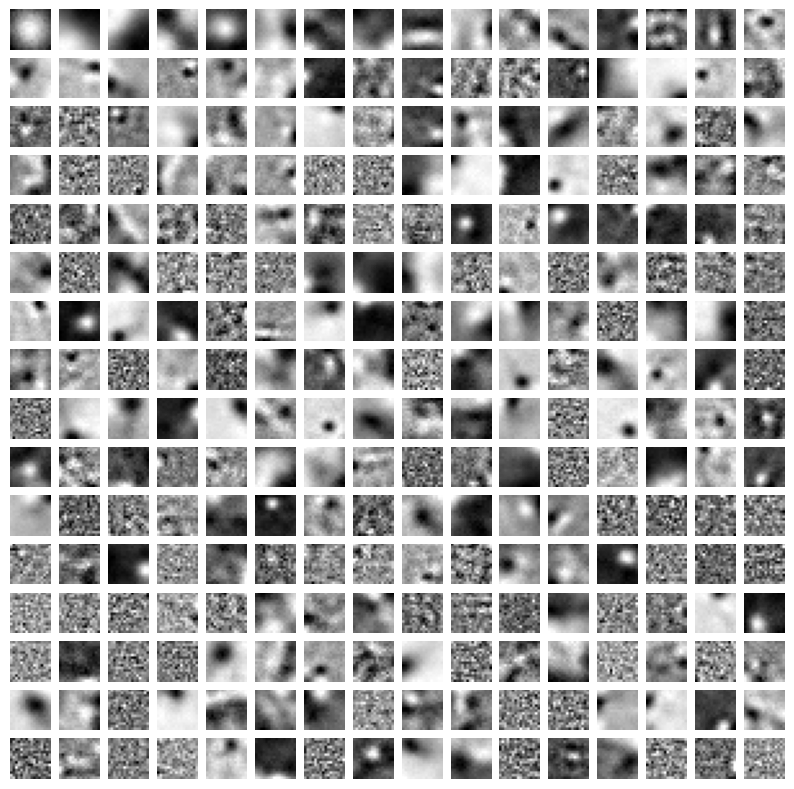

In [33]:
# Display learned dictionary atoms
grid_size = int(numpy.ceil(numpy.sqrt(V.shape[0])))
fig, axes = pyplot.subplots(grid_size, grid_size, figsize=(10, 10), frameon=False)
for idx, atom in enumerate(V):
    atom_image = atom.reshape(16, 16)  # Reshape to patch size
    ax = axes[idx // grid_size, idx % grid_size]
    ax.imshow(atom_image, cmap='gray')
    ax.axis('off')
pyplot.show()

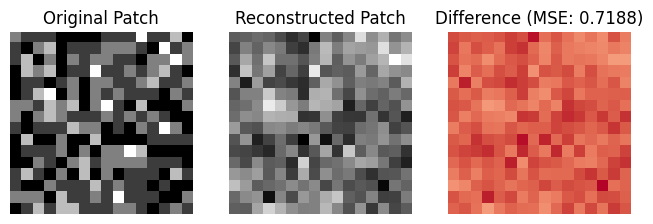

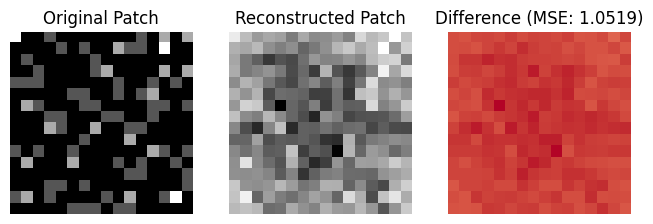

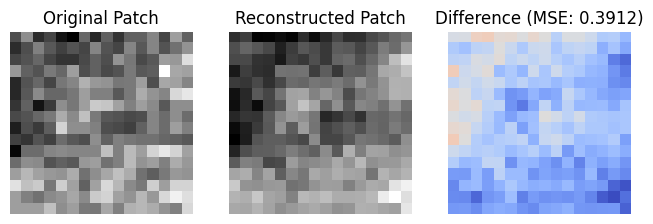

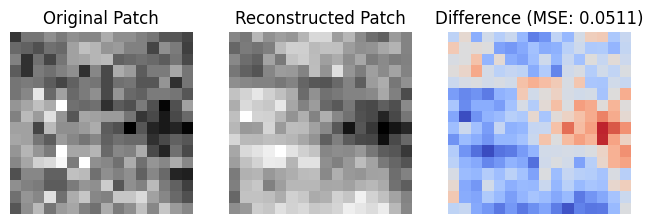

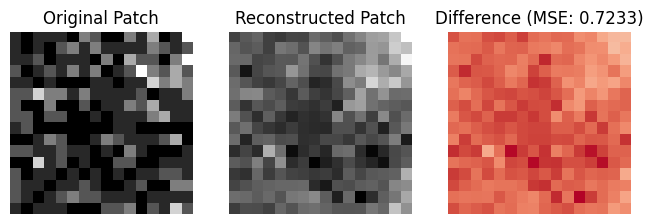

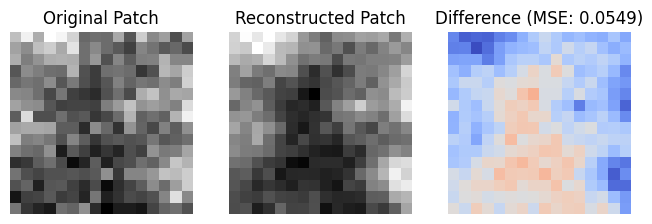

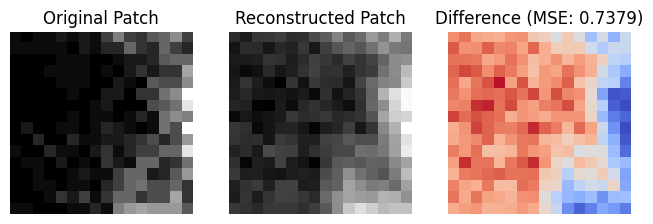

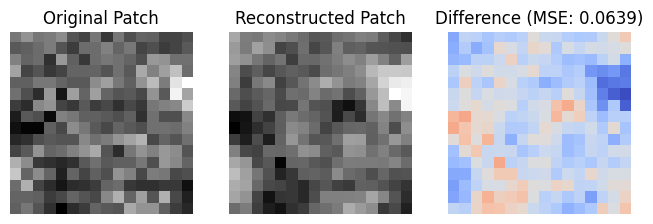

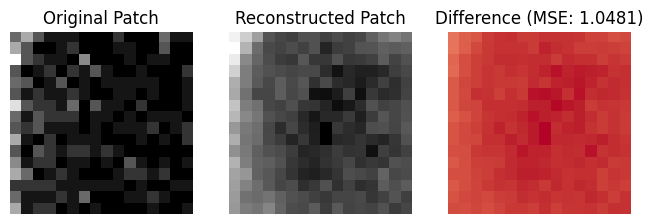

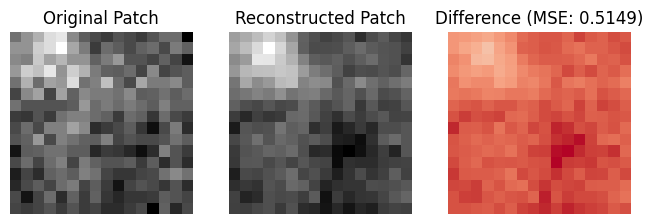

In [35]:
# Sample random patches and display their sparse codes
random_patches = random.sample(patches, 10)
for idx, patch in enumerate(random_patches):
    patch_flat = patch.flatten()
    patch_flat = (patch_flat - X_mean) / (X_std + 1e-8)  # Normalize the patch
    code = dico.transform(patch_flat.reshape(1, -1))

    fig, ax = pyplot.subplots(1, 3, figsize=(8, 4), frameon=False)
    ax[0].imshow(patch, cmap='gray')
    ax[0].set_title("Original Patch")
    ax[0].axis('off')

    reconstructed_patch = code @ V
    reconstructed_patch = reconstructed_patch.reshape(16, 16)
    ax[1].imshow(reconstructed_patch, cmap='gray')
    ax[1].set_title("Reconstructed Patch")
    ax[1].axis('off')

    # difference 
    diff = patch - reconstructed_patch
    mse = numpy.mean(diff**2)
    ax[2].imshow(diff, cmap='coolwarm', vmin=-numpy.max(numpy.abs(diff)), vmax=numpy.max(numpy.abs(diff)))
    ax[2].set_title(f"Difference (MSE: {mse:.4f})")
    ax[2].axis('off')

    pyplot.show()

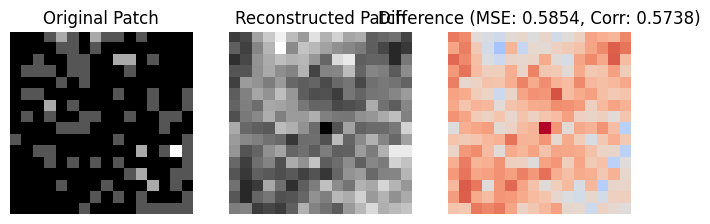

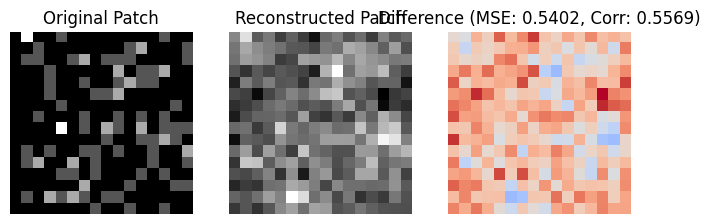

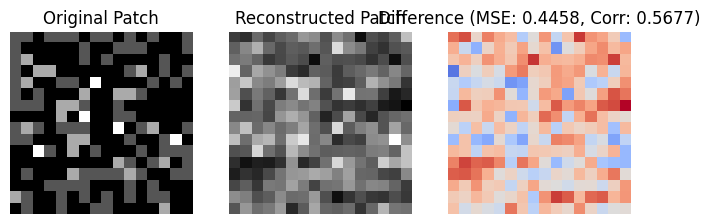

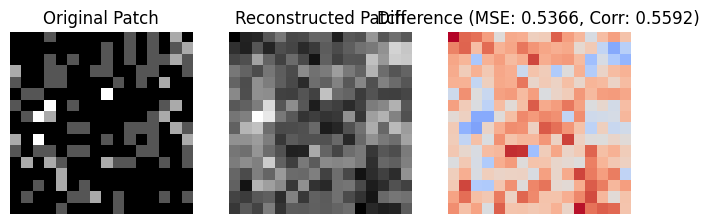

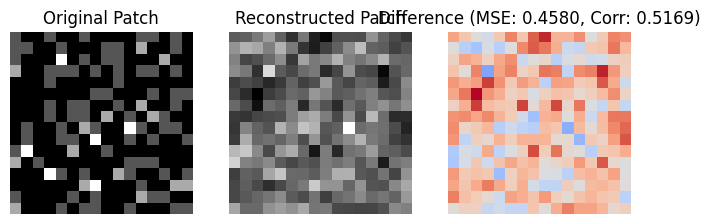

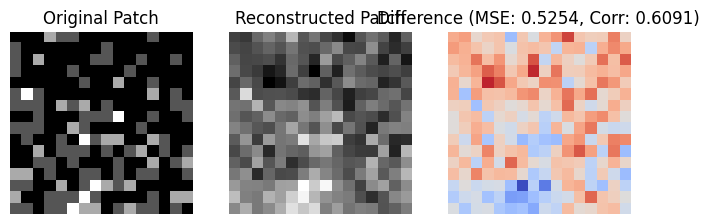

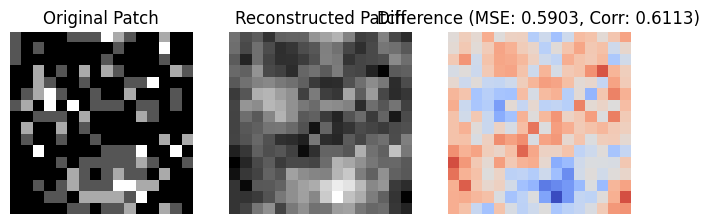

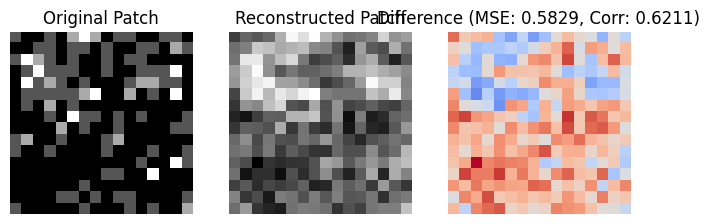

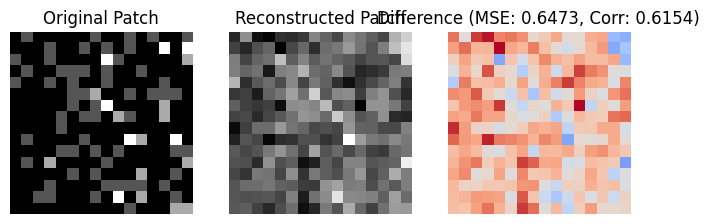

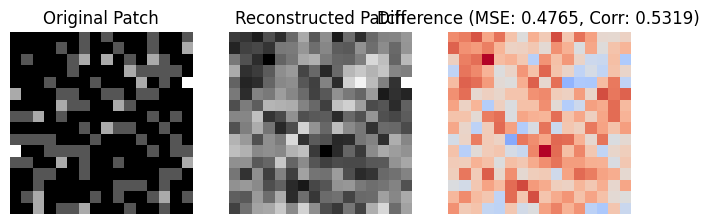

In [45]:
# Testing patches
random_idx = random.choice(range(len(dataset)))
sample = dataset[random_idx]
sample = sample.cpu().numpy()

testing_patches = extract_patches_with_foreground(sample, subsample_factor=0.1)
testing_patches = numpy.array(testing_patches)

for idx, patch in enumerate(testing_patches[:10]):
    patch_flat = patch.flatten()
    patch_flat = (patch_flat - X_mean) / (X_std + 1e-8)  # Normalize the patch
    code = dico.transform(patch_flat.reshape(1, -1))

    fig, ax = pyplot.subplots(1, 3, figsize=(8, 4), frameon=False)
    ax[0].imshow(patch, cmap='gray')
    ax[0].set_title("Original Patch")
    ax[0].axis('off')

    reconstructed_patch = code @ V
    reconstructed_patch = reconstructed_patch.reshape(16, 16)
    ax[1].imshow(reconstructed_patch, cmap='gray')
    ax[1].set_title("Reconstructed Patch")
    ax[1].axis('off')

    diff = patch - reconstructed_patch
    mse = numpy.mean(diff**2)
    corr = numpy.corrcoef(patch.flatten(), reconstructed_patch.flatten())[0,1]
    ax[2].imshow(diff, cmap='coolwarm', vmin=-numpy.max(numpy.abs(diff)), vmax=numpy.max(numpy.abs(diff)))
    # ax[2].set_title(f"Difference (MSE: {mse:.4f})")
    ax[2].set_title(f"Difference (MSE: {mse:.4f}, Corr: {corr:.4f})")
    ax[2].axis('off')
    pyplot.show()

In [46]:
# Export the dictionary and the mean/std for later use

numpy.savez("dictionary_learning_results.npz", dictionary=V, mean=X_mean, std=X_std)